<a href="https://colab.research.google.com/github/MDRobiulhassan/Mental-Health/blob/main/Ecommerece%20Fraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
!pip install kagglehub

In [49]:
import warnings
warnings.filterwarnings('ignore')

In [50]:
import kagglehub

path = kagglehub.dataset_download("umuttuygurr/e-commerce-fraud-detection-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'e-commerce-fraud-detection-dataset' dataset.
Path to dataset files: /kaggle/input/e-commerce-fraud-detection-dataset


In [51]:
import os

print(os.listdir(path))

['transactions.csv']


In [52]:
import pandas as pd

file_path = path + "/transactions.csv"
df = pd.read_csv(file_path)

df.head()

,transaction_id,user_id,account_age_days,total_transactions_user,avg_amount_user,amount,country,bin_country,channel,merchant_category,promo_used,avs_match,cvv_result,three_ds_flag,transaction_time,shipping_distance_km,is_fraud
0,1,1,141,47,147.93,84.75,FR,FR,web,travel,0,1,1,1,2024-01-06T04:09:39Z,370.95,0
1,2,1,141,47,147.93,107.90,FR,FR,web,travel,0,0,0,0,2024-01-09T20:13:47Z,149.62,0
2,3,1,141,47,147.93,92.36,FR,FR,app,travel,1,1,1,1,2024-01-12T06:20:11Z,164.08,0
3,4,1,141,47,147.93,112.47,FR,FR,web,fashion,0,1,1,1,2024-01-15T17:00:04Z,397.40,0
4,5,1,141,47,147.93,132.91,FR,US,web,electronics,0,1,1,1,2024-01-17T01:27:31Z,935.28,0


In [53]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299695 entries, 0 to 299694
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   transaction_id           299695 non-null  int64  
 1   user_id                  299695 non-null  int64  
 2   account_age_days         299695 non-null  int64  
 3   total_transactions_user  299695 non-null  int64  
 4   avg_amount_user          299695 non-null  float64
 5   amount                   299695 non-null  float64
 6   country                  299695 non-null  object 
 7   bin_country              299695 non-null  object 
 8   channel                  299695 non-null  object 
 9   merchant_category        299695 non-null  object 
 10  promo_used               299695 non-null  int64  
 11  avs_match                299695 non-null  int64  
 12  cvv_result               299695 non-null  int64  
 13  three_ds_flag            299695 non-null  int64  
 14  tran

# Data Preprocessing

In [55]:
df.isna().sum() / len(df)

,0
transaction_id,0.0
user_id,0.0
account_age_days,0.0
total_transactions_user,0.0
avg_amount_user,0.0
amount,0.0
country,0.0
bin_country,0.0
channel,0.0
merchant_category,0.0


In [56]:
df.duplicated().sum()

np.int64(0)

## Outlier Handling

In [57]:
df.drop(['transaction_id', 'user_id'], axis=1, inplace=True)

In [58]:
df['transaction_time'] = pd.to_datetime(df['transaction_time'])

df['hour'] = df['transaction_time'].dt.hour
df['day'] = df['transaction_time'].dt.day
df['month'] = df['transaction_time'].dt.month
df['weekday'] = df['transaction_time'].dt.weekday

df.drop('transaction_time', axis=1, inplace=True)

In [59]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
account_age_days,299695.0,973.397871,525.241409,1.00,516.00,975.00,1425.00,1890.00
total_transactions_user,299695.0,50.673321,5.976391,40.00,46.00,51.00,56.00,60.00
avg_amount_user,299695.0,148.142973,200.364624,3.52,46.19,90.13,173.45,4565.29
amount,299695.0,177.165279,306.926507,1.00,42.10,89.99,191.11,16994.74
promo_used,299695.0,0.153640,0.360603,0.00,0.00,0.00,0.00,1.00
avs_match,299695.0,0.837999,0.368453,0.00,1.00,1.00,1.00,1.00
cvv_result,299695.0,0.872110,0.333968,0.00,1.00,1.00,1.00,1.00
three_ds_flag,299695.0,0.784588,0.411109,0.00,1.00,1.00,1.00,1.00
shipping_distance_km,299695.0,357.049028,427.672074,0.00,136.60,273.02,409.18,3748.56
is_fraud,299695.0,0.022062,0.146887,0.00,0.00,0.00,0.00,1.00


In [60]:
continuous_features = [
    'account_age_days',
    'total_transactions_user',
    'avg_amount_user',
    'amount',
    'shipping_distance_km'
]

In [61]:
import pandas as pd

outlier_summary = []

numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()

    if outlier_count > 0:
        outlier_summary.append({
            'feature': col,
            'Q1': Q1,
            'Q3': Q3,
            'lower_bound': lower,
            'upper_bound': upper,
            'outlier_count': outlier_count
        })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,feature,Q1,Q3,lower_bound,upper_bound,outlier_count
0,avg_amount_user,46.19,173.45,-144.700,364.340,23890
1,amount,42.10,191.11,-181.415,414.625,26711
2,promo_used,0.00,0.00,0.000,0.000,46045
3,avs_match,1.00,1.00,1.000,1.000,48551
4,cvv_result,1.00,1.00,1.000,1.000,38328
5,three_ds_flag,1.00,1.00,1.000,1.000,64558
6,shipping_distance_km,136.60,409.18,-272.270,818.050,20312
7,is_fraud,0.00,0.00,0.000,0.000,6612


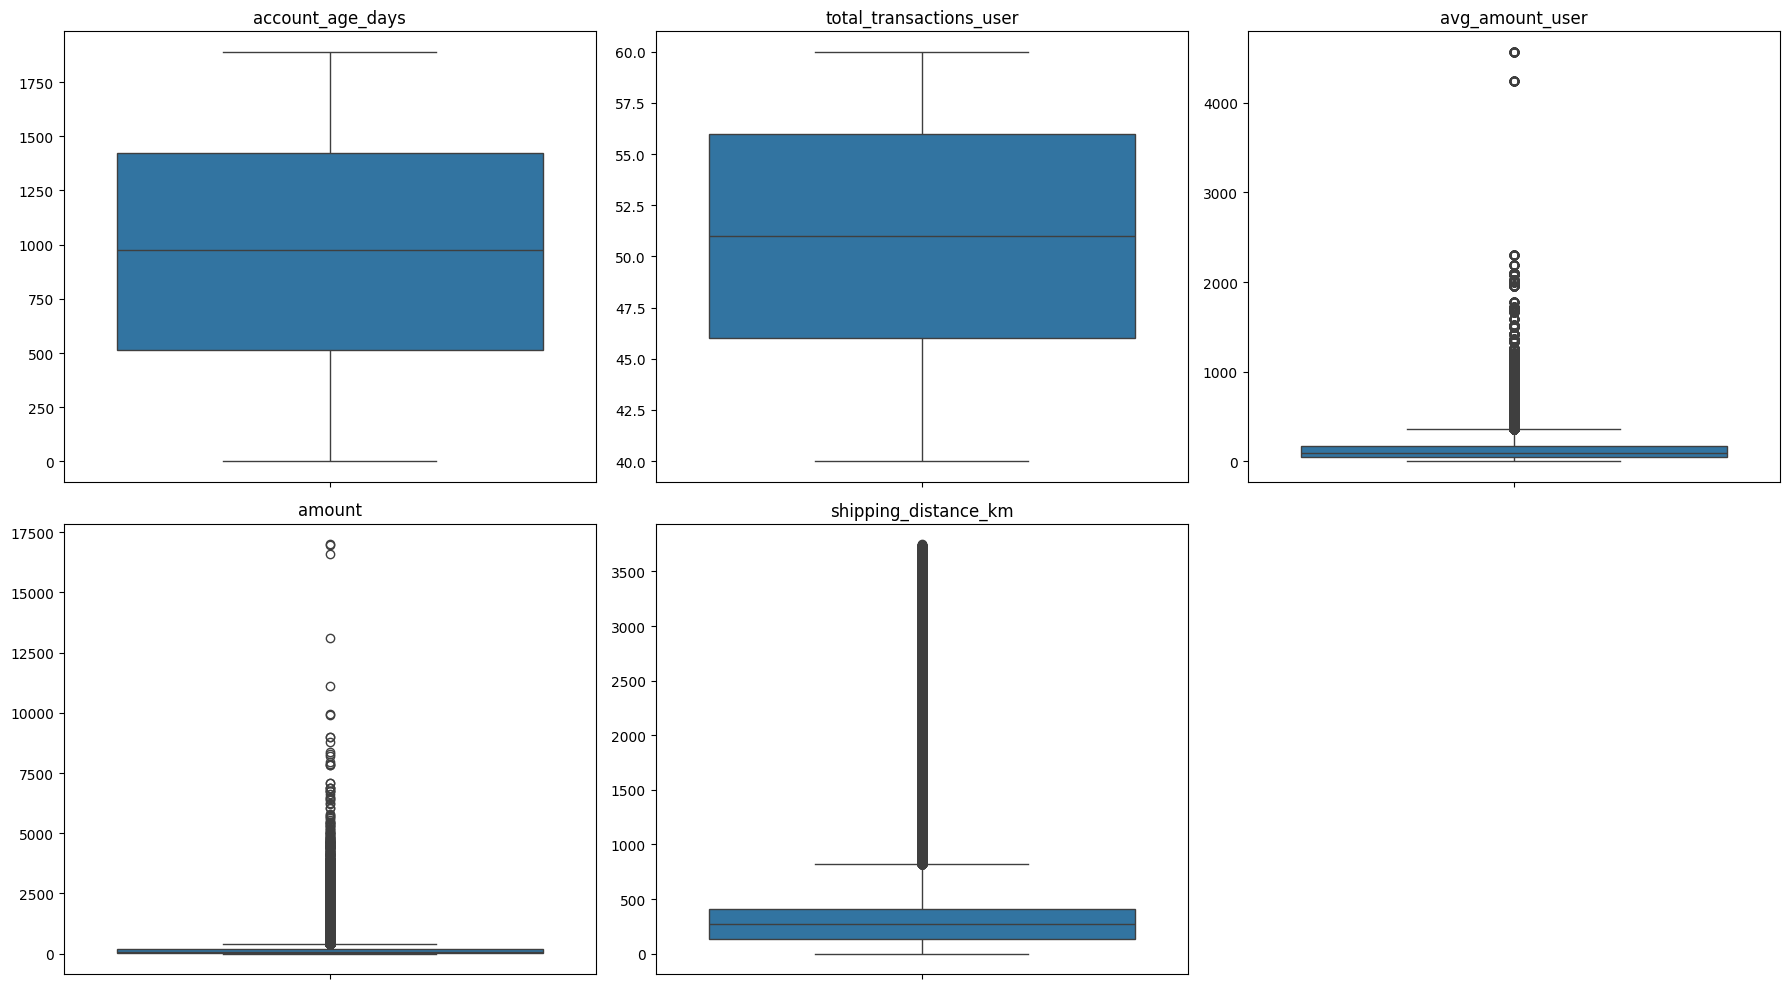

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_features = continuous_features

rows = 2
cols = 3
fig, axes = plt.subplots(rows, cols, figsize=(18, 10))

axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    if i < len(axes):
        sns.boxplot(y=df[feature], ax=axes[i])
        axes[i].set_title(feature)
        axes[i].set_ylabel('')

for j in range(len(numeric_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [63]:
for feature in numeric_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[feature] = df[feature].clip(lower, upper)

In [64]:
capped_summary = []

for feature in numeric_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    capped_summary.append([feature, Q1, Q3, lower, upper, 0])

capped_df = pd.DataFrame(capped_summary, columns=['feature','Q1','Q3','lower_bound','upper_bound','outlier_count'])

capped_df

,feature,Q1,Q3,lower_bound,upper_bound,outlier_count
0,account_age_days,516.00,1425.00,-847.500,2788.500,0
1,total_transactions_user,46.00,56.00,31.000,71.000,0
2,avg_amount_user,46.19,173.45,-144.700,364.340,0
3,amount,42.10,191.11,-181.415,414.625,0
4,shipping_distance_km,136.60,409.18,-272.270,818.050,0


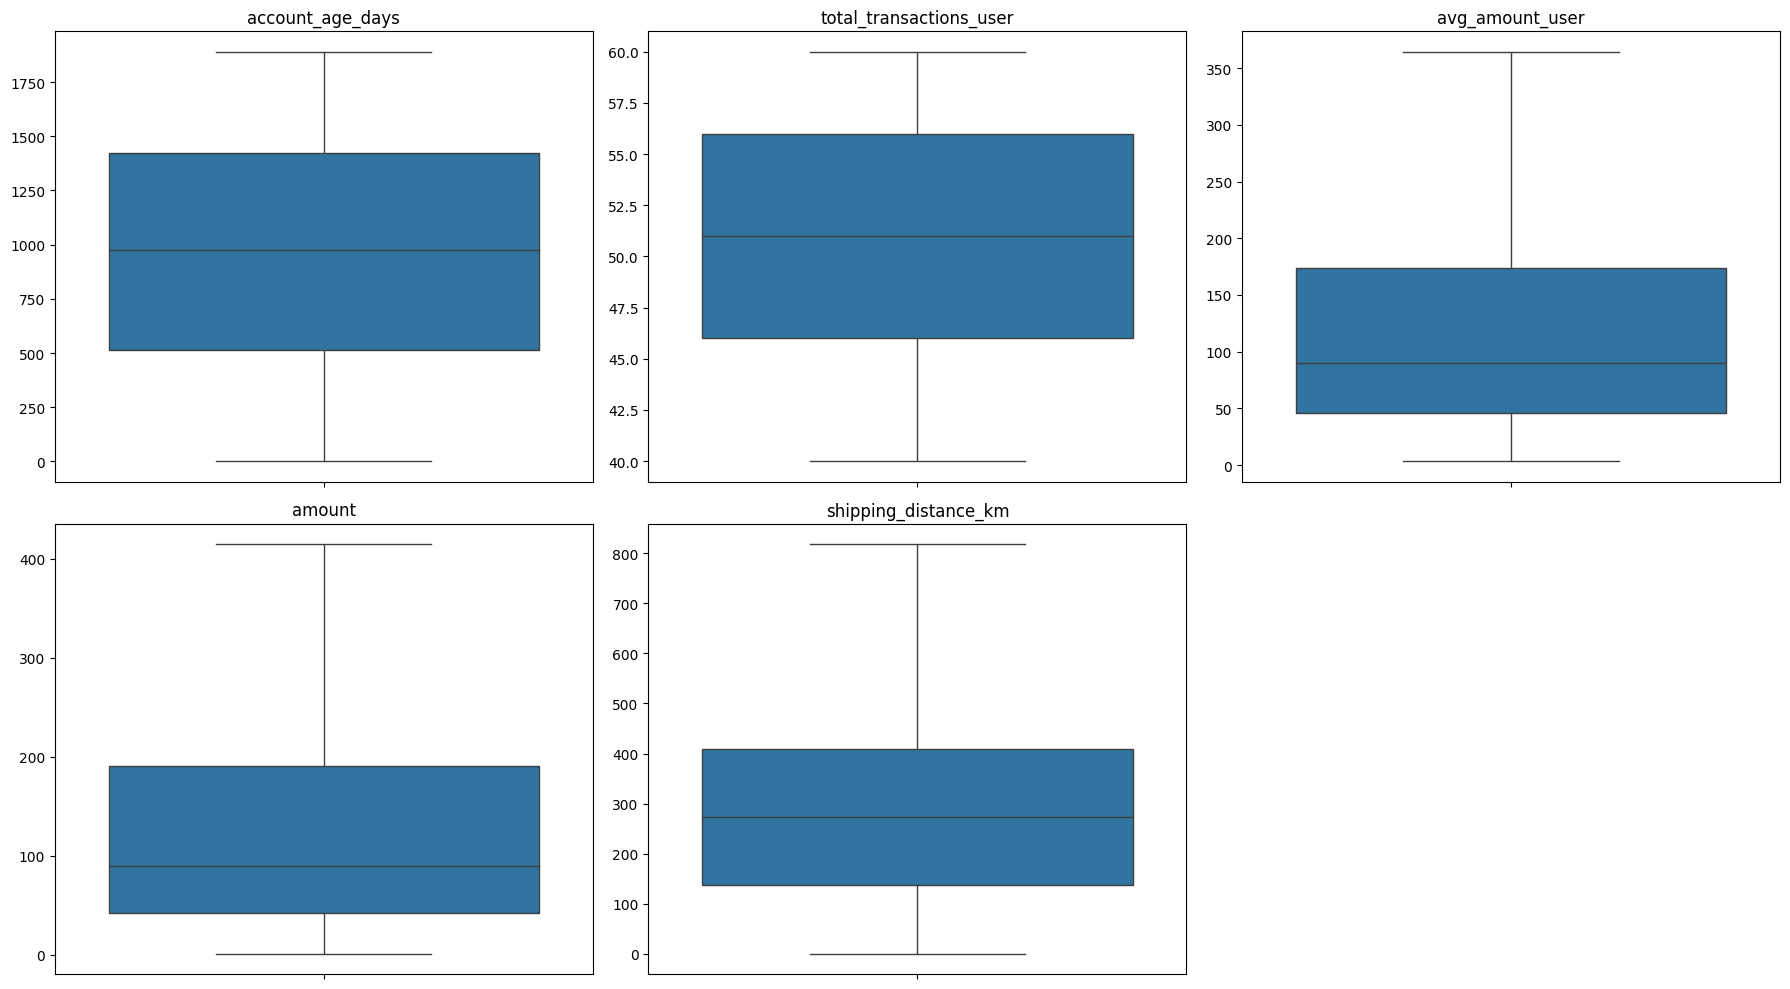

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_features = continuous_features

rows = 2
cols = 3
fig, axes = plt.subplots(rows, cols, figsize=(18, 10))

axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    if i < len(axes):
        sns.boxplot(y=df[feature], ax=axes[i])
        axes[i].set_title(feature)
        axes[i].set_ylabel('')

for j in range(len(numeric_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Data Aggregation

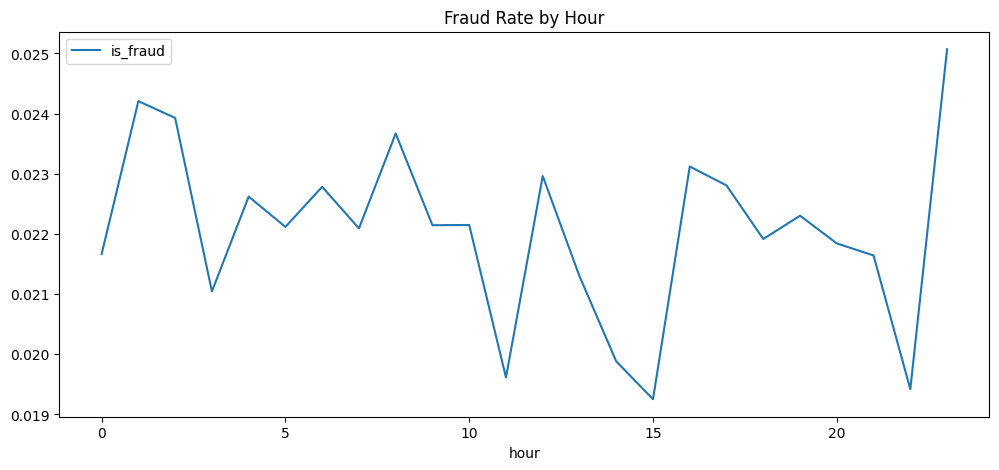

In [66]:
agg_hour = pd.pivot_table(
    data=df,
    index='hour',
    values='is_fraud',
    aggfunc='mean'
)

plt.figure(figsize=(12,5))
sns.lineplot(data=agg_hour)
plt.title('Fraud Rate by Hour')
plt.show()

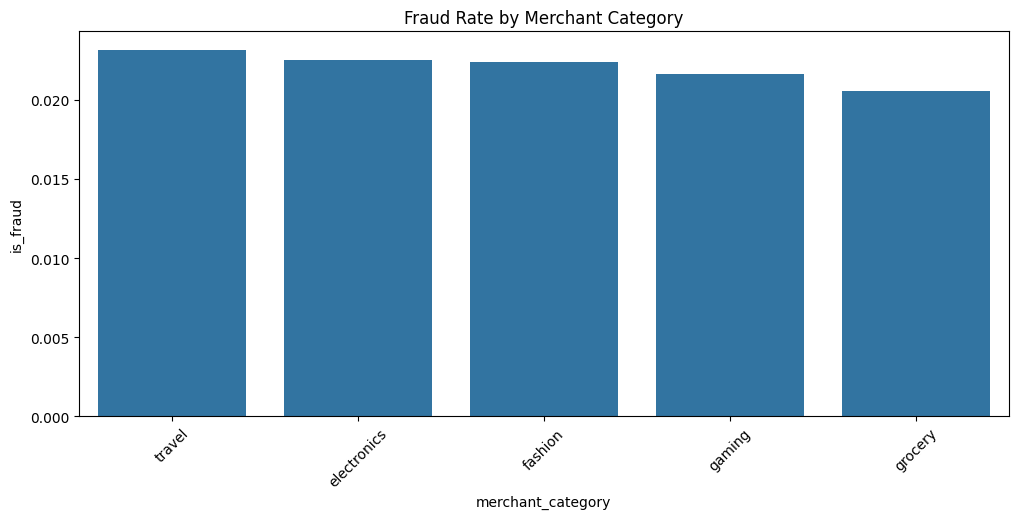

In [67]:
agg_merchant = pd.pivot_table(
    data=df,
    index='merchant_category',
    values='is_fraud',
    aggfunc='mean'
).sort_values(by='is_fraud', ascending=False)

plt.figure(figsize=(12,5))
sns.barplot(x=agg_merchant.index, y=agg_merchant['is_fraud'])
plt.xticks(rotation=45)
plt.title('Fraud Rate by Merchant Category')
plt.show()

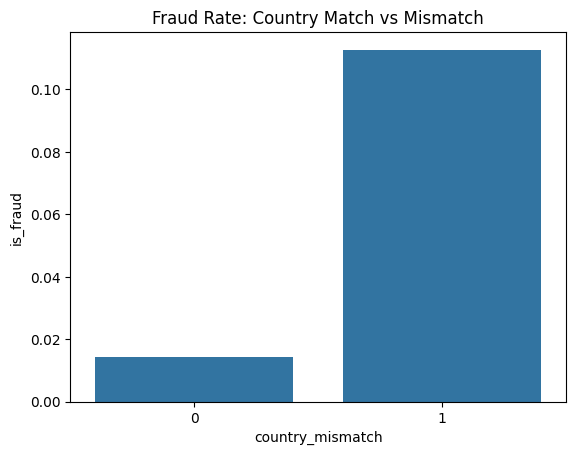

In [68]:
df['country_mismatch'] = (df['country'] != df['bin_country']).astype(int)

agg_mismatch = pd.pivot_table(
    data=df,
    index='country_mismatch',
    values='is_fraud',
    aggfunc='mean'
)

sns.barplot(x=agg_mismatch.index, y=agg_mismatch['is_fraud'])
plt.title('Fraud Rate: Country Match vs Mismatch')
plt.show()

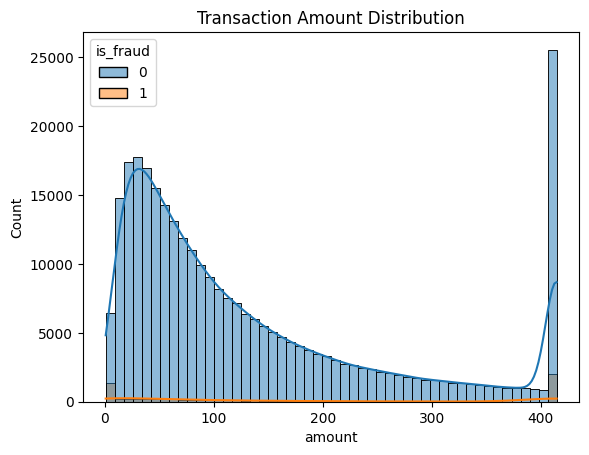

In [69]:
sns.histplot(data=df, x='amount', hue='is_fraud', bins=50, kde=True)
plt.title('Transaction Amount Distribution')
plt.show()

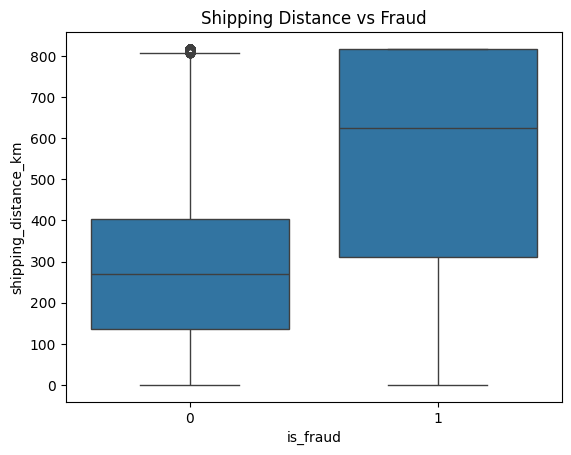

In [70]:
sns.boxplot(x='is_fraud', y='shipping_distance_km', data=df)
plt.title('Shipping Distance vs Fraud')
plt.show()

# Feature Scaling

In [100]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score
import sklearn.neighbors
import pandas as pd
from sklearn.utils import shuffle

X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

numerical_cols = X.select_dtypes(include=np.number).columns.tolist()

X_processed = X[numerical_cols]

X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)

In [72]:
import numpy as np
import sklearn.neighbors
import pandas as pd

def get_knn(df, n, k, metric):

    """
    Display k nearest neighbors:
    param df: Pandas DataFrame used to find similar objects within it
    param n: number of the object for which k nearest neighbors are sought
    param k: number of k nearest neighbors to be displayed
    param metric: name of the distance metric
    """

    nbrs = sklearn.neighbors.NearestNeighbors(n_neighbors = k, metric = metric, algorithm = 'brute')
    nbrs.fit(df[continuous_features])
    query_point = df[continuous_features].iloc[[n]]
    nbrs_distances, nbrs_indices = nbrs.kneighbors(query_point, k, return_distance=True)

    df_res = pd.concat([
        df.iloc[nbrs_indices[0]],
        pd.DataFrame(nbrs_distances.T, index=nbrs_indices[0], columns=['distance'])
        ], axis=1)

    return df_res

In [73]:
get_knn(df, 1, 50, 'euclidean')

,account_age_days,total_transactions_user,avg_amount_user,amount,country,bin_country,channel,merchant_category,promo_used,avs_match,cvv_result,three_ds_flag,shipping_distance_km,is_fraud,hour,day,month,weekday,country_mismatch,distance
1,141,47,147.93,107.90,FR,FR,web,travel,0,0,0,0,149.62,0,20,9,1,1,0,0.000000
184981,137,43,137.56,105.77,GB,GB,app,travel,0,1,1,1,147.47,0,8,24,1,2,0,12.194109
254717,150,43,148.66,104.76,DE,DE,app,electronics,0,1,1,1,142.23,0,1,13,4,5,0,12.728103
31,141,47,147.93,119.62,FR,FR,web,gaming,0,1,1,1,141.98,0,14,6,7,5,0,13.990282
43,141,47,147.93,123.80,FR,FR,app,electronics,0,1,1,1,156.49,0,19,4,10,4,0,17.320707
254731,150,43,148.66,119.08,DE,DE,app,grocery,0,1,1,1,136.36,0,19,26,6,2,0,19.958780
2,141,47,147.93,92.36,FR,FR,app,travel,1,1,1,1,164.08,0,6,12,1,4,0,21.226945
296488,125,52,140.01,100.30,IT,IT,web,gaming,0,1,0,0,161.30,0,16,1,7,0,0,23.192861
223886,126,58,137.10,99.81,ES,ES,app,grocery,0,1,1,1,144.60,0,8,24,3,6,0,23.535875
87260,159,59,148.58,116.89,TR,TR,app,fashion,0,0,0,1,143.18,0,16,22,7,0,0,24.304654


In [74]:
get_knn(df, 1, 50, 'manhattan')

,account_age_days,total_transactions_user,avg_amount_user,amount,country,bin_country,channel,merchant_category,promo_used,avs_match,cvv_result,three_ds_flag,shipping_distance_km,is_fraud,hour,day,month,weekday,country_mismatch,distance
1,141,47,147.93,107.90,FR,FR,web,travel,0,0,0,0,149.62,0,20,9,1,1,0,0.00
31,141,47,147.93,119.62,FR,FR,web,gaming,0,1,1,1,141.98,0,14,6,7,5,0,19.36
184981,137,43,137.56,105.77,GB,GB,app,travel,0,1,1,1,147.47,0,8,24,1,2,0,22.65
43,141,47,147.93,123.80,FR,FR,app,electronics,0,1,1,1,156.49,0,19,4,10,4,0,22.77
254717,150,43,148.66,104.76,DE,DE,app,electronics,0,1,1,1,142.23,0,1,13,4,5,0,24.26
2,141,47,147.93,92.36,FR,FR,app,travel,1,1,1,1,164.08,0,6,12,1,4,0,30.00
33,141,47,147.93,94.76,FR,FR,web,fashion,0,1,1,1,174.34,0,10,17,7,2,0,37.86
254731,150,43,148.66,119.08,DE,DE,app,grocery,0,1,1,1,136.36,0,19,26,6,2,0,38.17
87260,159,59,148.58,116.89,TR,TR,app,fashion,0,0,0,1,143.18,0,16,22,7,0,0,46.08
279953,161,43,136.83,100.63,DE,DE,app,travel,1,0,0,0,155.21,0,4,21,9,5,0,47.96


In [75]:
feature_names = continuous_features

In [76]:
transformer_mas = sklearn.preprocessing.MaxAbsScaler().fit(df[feature_names])
df_scaled = df.copy()
df_scaled[feature_names] = df_scaled[feature_names].astype(float)
df_scaled.loc[:, feature_names] = transformer_mas.transform(df_scaled[feature_names])

In [77]:
get_knn(df_scaled, 1, 10, 'manhattan')

,account_age_days,total_transactions_user,avg_amount_user,amount,country,bin_country,channel,merchant_category,promo_used,avs_match,cvv_result,three_ds_flag,shipping_distance_km,is_fraud,hour,day,month,weekday,country_mismatch,distance
1,0.074603,0.783333,0.406022,0.260235,FR,FR,web,travel,0,0,0,0,0.182898,0,20,9,1,1,0,0.000000
31,0.074603,0.783333,0.406022,0.288502,FR,FR,web,gaming,0,1,1,1,0.173559,0,14,6,7,5,0,0.037606
43,0.074603,0.783333,0.406022,0.298583,FR,FR,app,electronics,0,1,1,1,0.191296,0,19,4,10,4,0,0.046746
2,0.074603,0.783333,0.406022,0.222756,FR,FR,app,travel,1,1,1,1,0.200575,0,6,12,1,4,0,0.055156
33,0.074603,0.783333,0.406022,0.228544,FR,FR,web,fashion,0,1,1,1,0.213117,0,10,17,7,2,0,0.061909
254717,0.079365,0.716667,0.408025,0.252662,DE,DE,app,electronics,0,1,1,1,0.173865,0,1,13,4,5,0,0.090039
22570,0.034921,0.783333,0.408986,0.252035,RO,RO,web,gaming,1,0,0,0,0.226099,1,6,12,8,0,0,0.094047
184981,0.072487,0.716667,0.377559,0.255098,GB,GB,app,travel,0,1,1,1,0.180270,0,8,24,1,2,0,0.105011
44462,0.044974,0.816667,0.410331,0.249647,ES,ES,app,gaming,0,1,1,1,0.213813,0,19,20,7,5,0,0.108775
279693,0.118519,0.750000,0.390981,0.262623,FR,FR,web,electronics,1,0,1,1,0.165931,0,23,19,5,6,0,0.111644


## Normalization

In [78]:
from sklearn.preprocessing import MinMaxScaler

std = MinMaxScaler().fit(X_train)

X_train_std = std.transform(X_train)

X_test_std = std.transform(X_test)

## Standardization

In [79]:
beforeScaling_lr = LogisticRegression(random_state = 42)

In [80]:
beforeScaling_lr = LogisticRegression(random_state = 42)
beforeScaling_lr.fit(X_train, y_train)
y_predict_valid_lr = beforeScaling_lr.predict(X_test)
y_probability_valid_lr = beforeScaling_lr.predict_proba(X_test)[:, 1]
print('F1 score =', f1_score(y_test, y_predict_valid_lr))
print('AUC-ROC score =', roc_auc_score(y_test, y_probability_valid_lr))

F1 score = 0.39329608938547483
AUC-ROC score = 0.9176271763079993


In [81]:
scaler = StandardScaler()

In [82]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [83]:
afterScaling_lr = LogisticRegression(random_state = 42)

In [84]:
afterScaling_lr = LogisticRegression(random_state = 42)
afterScaling_lr.fit(X_train_scaled, y_train)
y_predict_valid_lr = afterScaling_lr.predict(X_test_scaled)
y_probability_valid_lr = afterScaling_lr.predict_proba(X_test_scaled)[:, 1]
print('F1 score =', f1_score(y_test, y_predict_valid_lr))
print('AUC-ROC score =', roc_auc_score(y_test, y_probability_valid_lr))

F1 score = 0.40982691233947516
AUC-ROC score = 0.9212002311370897


# Feature Selection

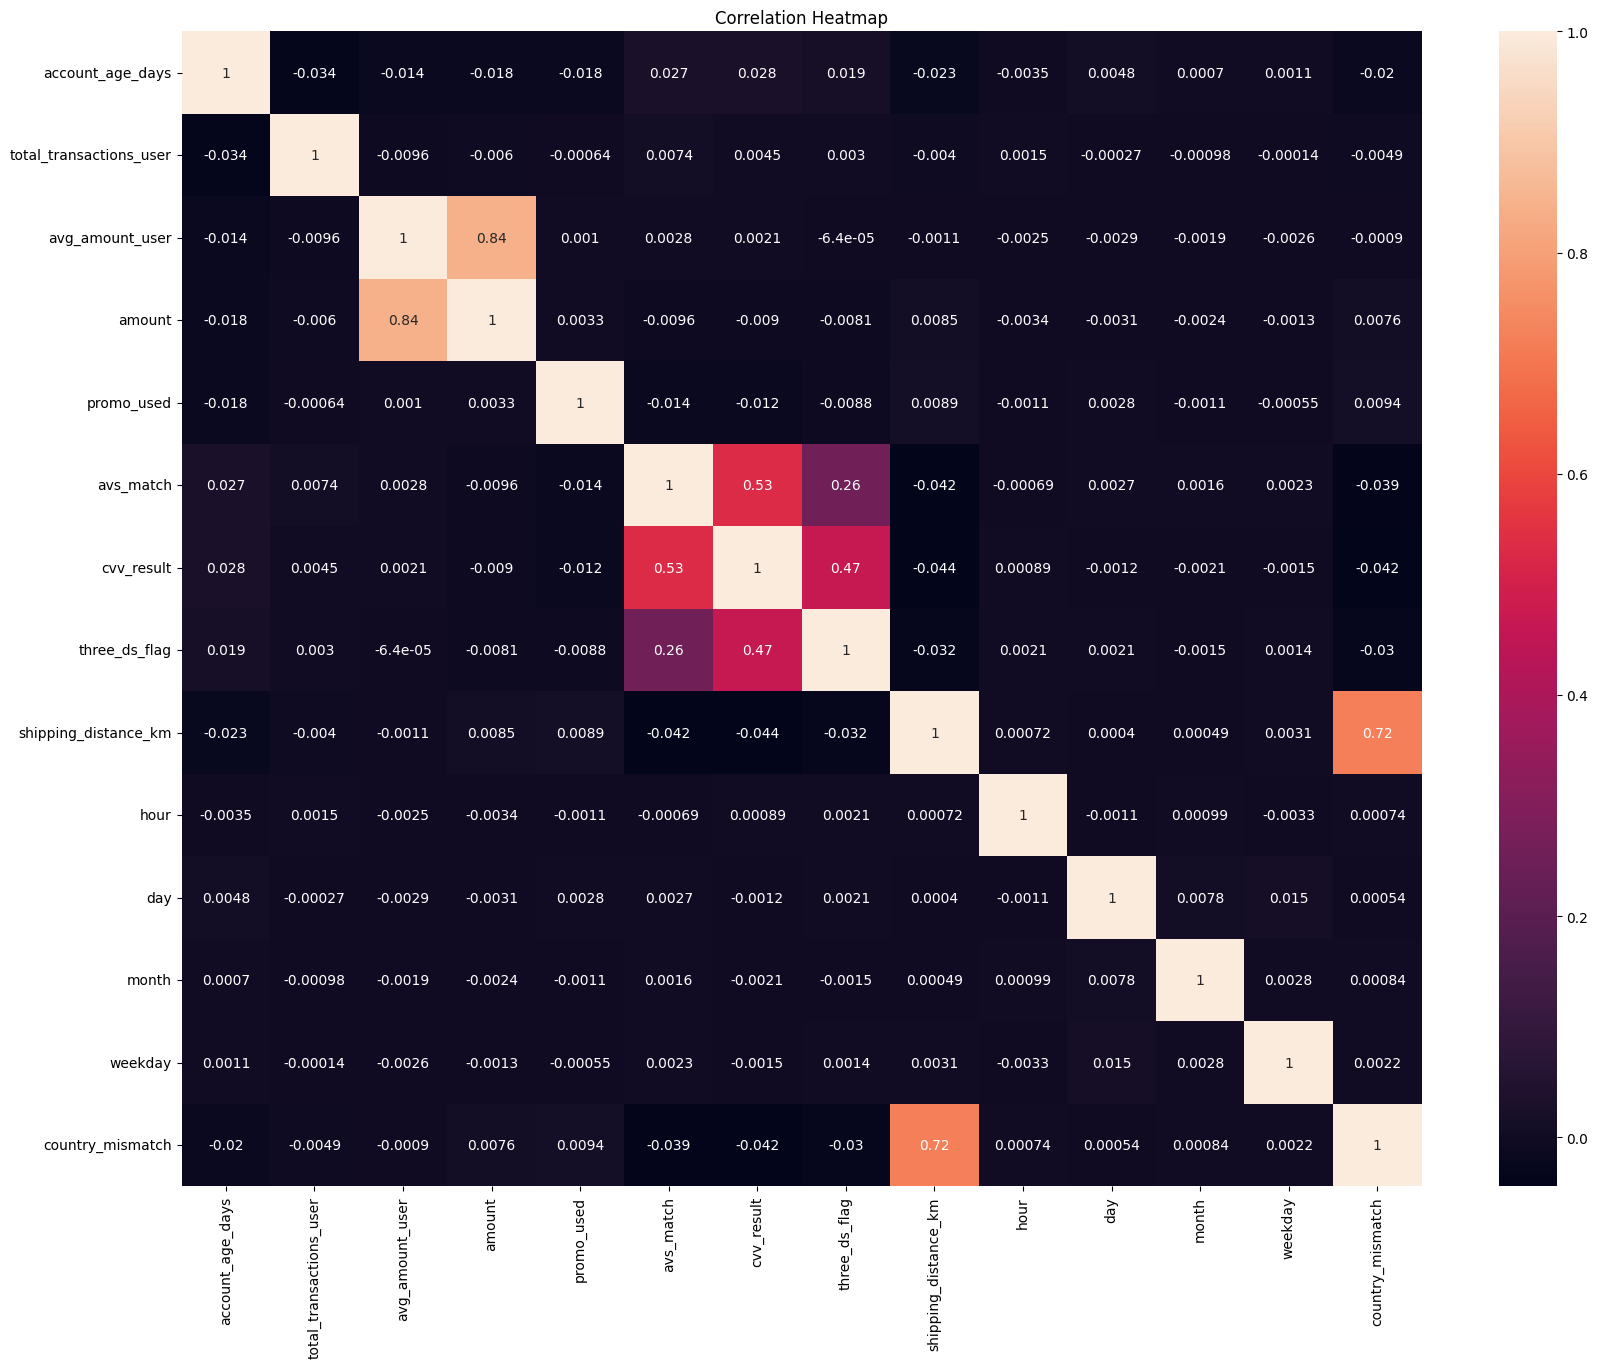

In [85]:
plt.figure(figsize=(20,15))
heatmap = sns.heatmap(X_processed.corr(), annot=True)
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':12});

In [86]:
correlation_matrix = X_processed.corr()
display(correlation_matrix)

,account_age_days,total_transactions_user,avg_amount_user,amount,promo_used,avs_match,cvv_result,three_ds_flag,shipping_distance_km,hour,day,month,weekday,country_mismatch
account_age_days,1.000000,-0.034347,-0.014343,-0.018120,-0.018416,0.026525,0.027605,0.018643,-0.022637,-0.003458,0.004761,0.000696,0.001147,-0.019776
total_transactions_user,-0.034347,1.000000,-0.009590,-0.005989,-0.000636,0.007444,0.004464,0.002968,-0.004027,0.001508,-0.000266,-0.000976,-0.000144,-0.004857
avg_amount_user,-0.014343,-0.009590,1.000000,0.843178,0.001022,0.002845,0.002083,-0.000064,-0.001088,-0.002537,-0.002895,-0.001920,-0.002574,-0.000904
amount,-0.018120,-0.005989,0.843178,1.000000,0.003274,-0.009608,-0.008964,-0.008075,0.008460,-0.003373,-0.003079,-0.002441,-0.001270,0.007616
promo_used,-0.018416,-0.000636,0.001022,0.003274,1.000000,-0.013678,-0.012061,-0.008786,0.008868,-0.001148,0.002796,-0.001096,-0.000554,0.009394
avs_match,0.026525,0.007444,0.002845,-0.009608,-0.013678,1.000000,0.531155,0.255365,-0.041605,-0.000691,0.002694,0.001610,0.002324,-0.038995
cvv_result,0.027605,0.004464,0.002083,-0.008964,-0.012061,0.531155,1.000000,0.469381,-0.044270,0.000893,-0.001181,-0.002056,-0.001479,-0.042188
three_ds_flag,0.018643,0.002968,-0.000064,-0.008075,-0.008786,0.255365,0.469381,1.000000,-0.031643,0.002144,0.002123,-0.001536,0.001361,-0.029676
shipping_distance_km,-0.022637,-0.004027,-0.001088,0.008460,0.008868,-0.041605,-0.044270,-0.031643,1.000000,0.000723,0.000405,0.000486,0.003078,0.719583
hour,-0.003458,0.001508,-0.002537,-0.003373,-0.001148,-0.000691,0.000893,0.002144,0.000723,1.000000,-0.001110,0.000994,-0.003276,0.000742


In [87]:
df.drop('avg_amount_user', axis=1, inplace=True)

In [88]:
df_numeric_for_corr = pd.concat([X_processed, y], axis=1)
df_numeric_for_corr.corr()['is_fraud'].sort_values()

,is_fraud
avs_match,-0.223299
cvv_result,-0.218982
three_ds_flag,-0.162160
account_age_days,-0.120340
total_transactions_user,-0.017093
hour,-0.001911
month,-0.001106
avg_amount_user,-0.000848
weekday,0.000042
day,0.001353


In [89]:
df_numeric_for_corr.corr()['is_fraud'][df_numeric_for_corr.corr()['is_fraud']>0.1]

,is_fraud
shipping_distance_km,0.189741
country_mismatch,0.181083
is_fraud,1.000000


In [90]:
df_numeric_for_corr.corr()['is_fraud'][df_numeric_for_corr.corr()['is_fraud']<-0.1]

,is_fraud
account_age_days,-0.120340
avs_match,-0.223299
cvv_result,-0.218982
three_ds_flag,-0.162160


In [91]:
outliers = df[[
                     'shipping_distance_km',
                     'country_mismatch',
                     'account_age_days',
                     'avs_match',
                     'cvv_result',
                     'three_ds_flag']].copy()

In [92]:
from sklearn.neighbors import LocalOutlierFactor

model = LocalOutlierFactor(n_neighbors=20, contamination=df['is_fraud'].mean(), novelty=True)

model.fit(outliers)

outliers.loc[:, 'is_outlier'] = (model.predict(outliers) == -1)
outliers_knn = outliers['is_outlier'].sum()

print("Number of Anomalies: ", outliers_knn)

Number of Anomalies:  5877


In [93]:
outlier_keys = list(outliers[outliers['is_outlier'] == True].index)
good_keys = list(set(outliers.index) - set(outlier_keys))

In [94]:
df = df.drop(outlier_keys)
df.shape

(293818, 18)

# Handling Imbalanced Data

In [95]:
df['is_fraud'].value_counts()/df.shape[0] * 100

,count
is_fraud,
0,98.152598
1,1.847402


## Upsampling

In [96]:
# function to upsample
def upsample (features, target, repeat):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]

    features_upsampled = pd.concat([features_zeros] + [features_ones] * repeat)
    target_upsampled = pd.concat([target_zeros] + [target_ones] * repeat)

    features_upsampled, target_upsampled = shuffle (features_upsampled, target_upsampled, random_state = 42)

    return features_upsampled, target_upsampled

In [102]:
y_train.value_counts()

,count
is_fraud,
0,230712
1,4342


In [101]:
features_upsampled, target_upsampled = upsample(X_train, y_train, 4)

In [103]:
target_upsampled.value_counts()

,count
is_fraud,
0,230712
1,17368
